# Particles interacting in a Lennard Jones potential

In this notebook, we'll simulate particles interacting in a Lennard-Jones potential. The steps are going to be very similar to those we followed for the ideal gas simulation. The only difference is that we'll use **periodic boundary conditions** and we have to change our method for integrating the equations of motion since there are **forces** between the particles. 

## Assumptions and algorithm




## 1 Initial set up
Let's set up the initial variables and the positions and velocities of our particles at $t=0$. We will use the exact same method than we did for the ideal gas simulation. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import matplotlib.animation as animation
from IPython.display import HTML
plt.rcParams['figure.dpi'] = 300  
plt.rcParams['animation.embed_limit'] = 30

In [2]:
N = 100
radius = 0.3
L = 10
duration = 20 
nsteps = 2000
dt = duration/nsteps 
v0 = 1.5



grid_size = int(np.ceil(np.sqrt(N))) # Create enough positions in grid for the particles
spacing = L/ grid_size 
x = np.linspace(radius + spacing/2, L - radius - spacing/2, grid_size) 
pos = list(product(x, x))
positions = np.array(pos[:N]) 


theta = np.random.uniform(0, 2*np.pi, size=N)
vx,vy = v0*np.cos(theta), v0*np.sin(theta)
velocities = np.stack((vx,vy), axis=1)

## 2 Lennard-Jones potential

The Lennard-Jones (LJ) potential between two particles is given by: 

$$U_{LJ}(\vec r) = 4 \epsilon \left[ \left( \frac{\sigma}{r}\right)^{12} - \left( \frac{\sigma}{r}\right)^{6} \right],$$
where $r = \sqrt{x^2 + y^2}$ is the distance between the two particles. We will use reduced units $\epsilon \to 1$, $\sigma \to 1$ , i.e work in units of $\epsilon$ and $\sigma$. 
Usually, we introduce a cutoff $r_c$ such that $U_{LJ}(r > r_c) = 0.$ This is to avoid numerical errors when dividing by very small numbers. For this notebook, we'll take $r_c = 2.5$ units of $\sigma$. 


Text(0.5, 1.0, 'Lennard-Jones potential')

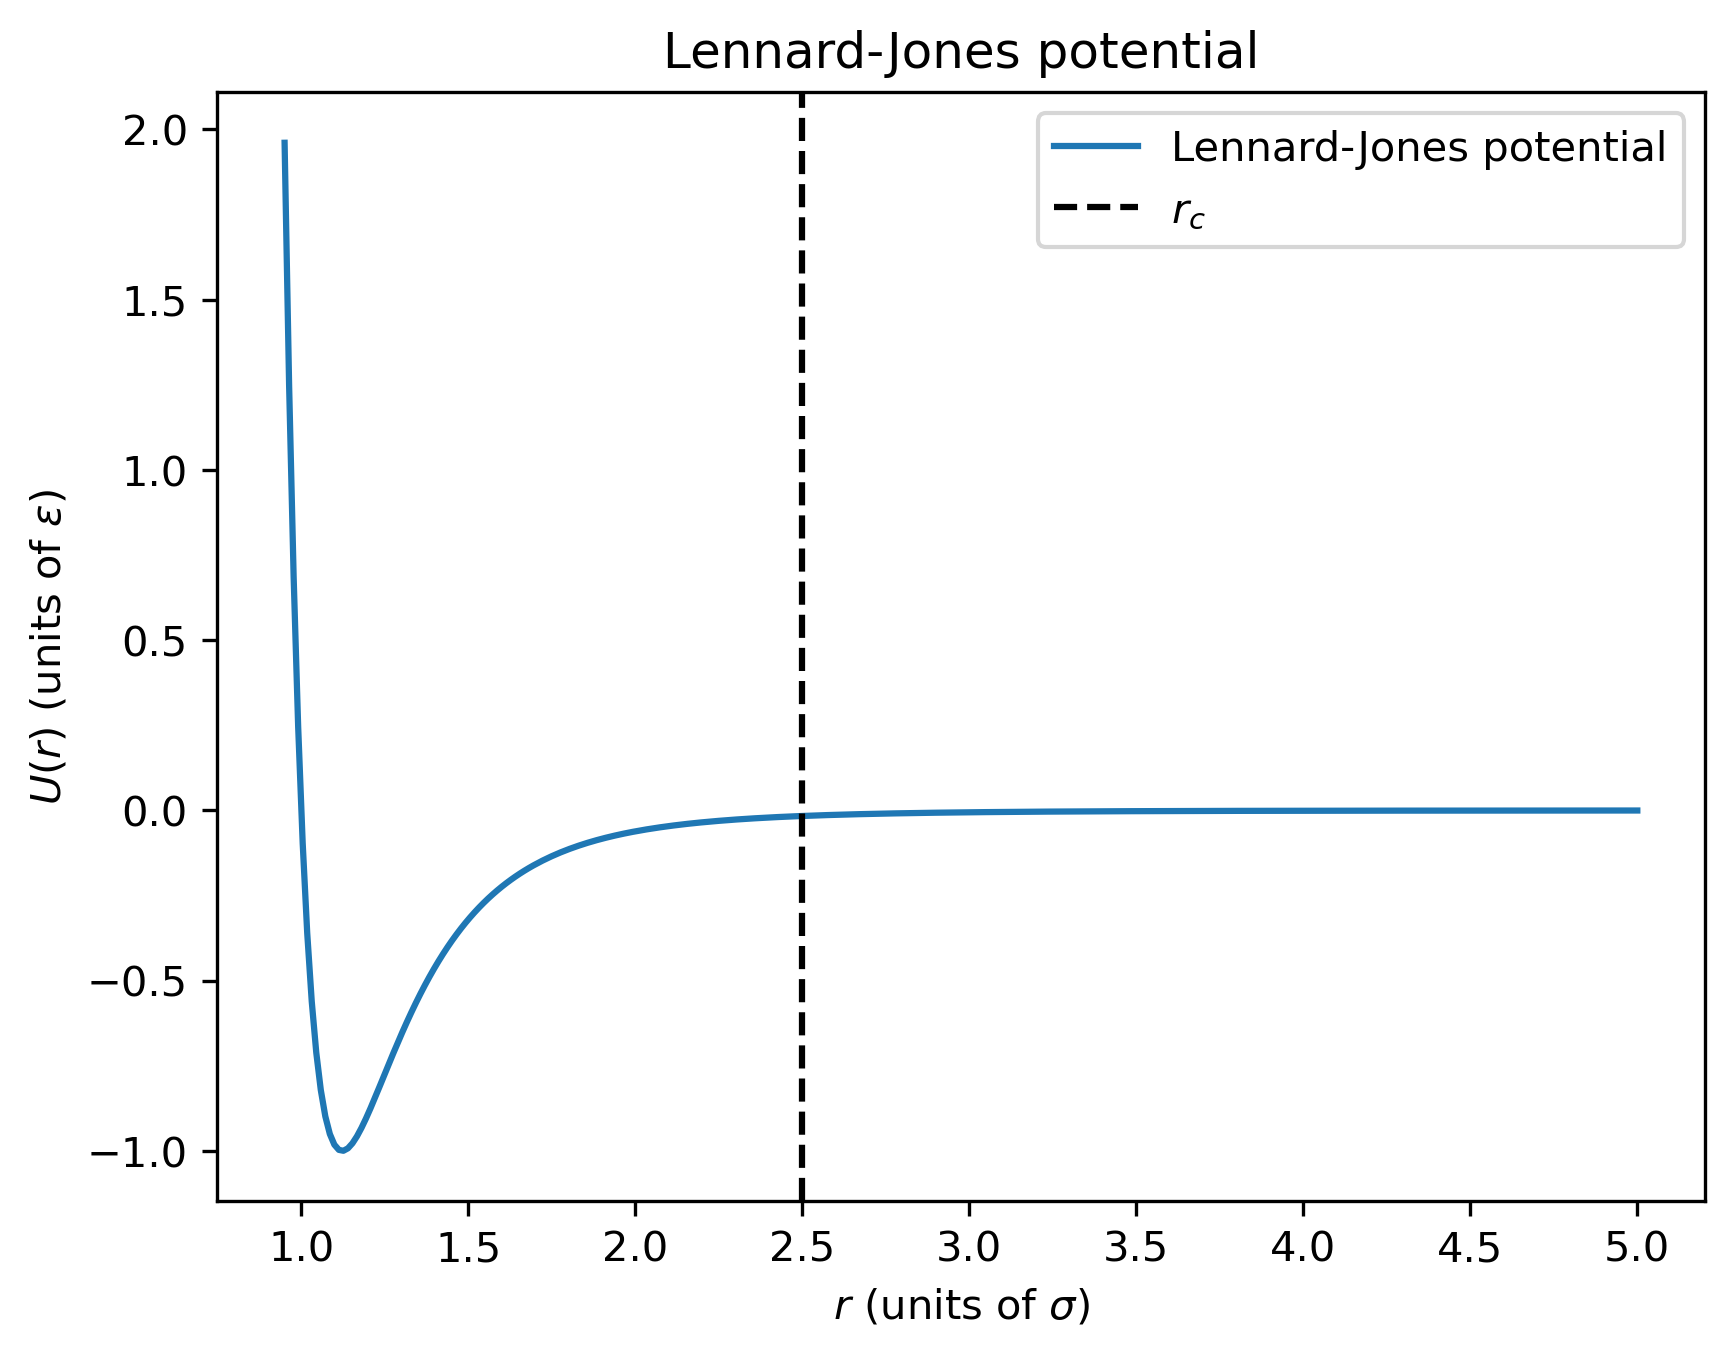

In [14]:
rc = 2.5 

ULJ = lambda r: 4*(1/r**12 - 1/r**6) # Lennard-Jones potential

r = np.linspace(0.95, 5, 300)

plt.plot(r, ULJ(r), label='Lennard-Jones potential')
plt.xlabel('$r$ (units of $\sigma$)',)
plt.ylabel('$U(r)$ (units of $\epsilon$)')
plt.axvline(rc, color='k', linestyle='--', label='$r_c$')
plt.legend()
plt.title('Lennard-Jones potential')

## 3. Resulting force 

The LJ potential induces a force that is proportional to the gradient of $U_{LJ}$: 

$$\vec F( \vec r)  = - \frac{\partial U_{LJ}}{\partial r} \vec u_r = $$


This is the force that appears in the equations of motion for the particles. In this section, we're going to first write a function that gets the vector between two particles using periodic boundary conditions. Since we're simulating an infinite system, we need to choose the vectors $\vec r$ such that their norms are the smalles between all replicas of the cell. 

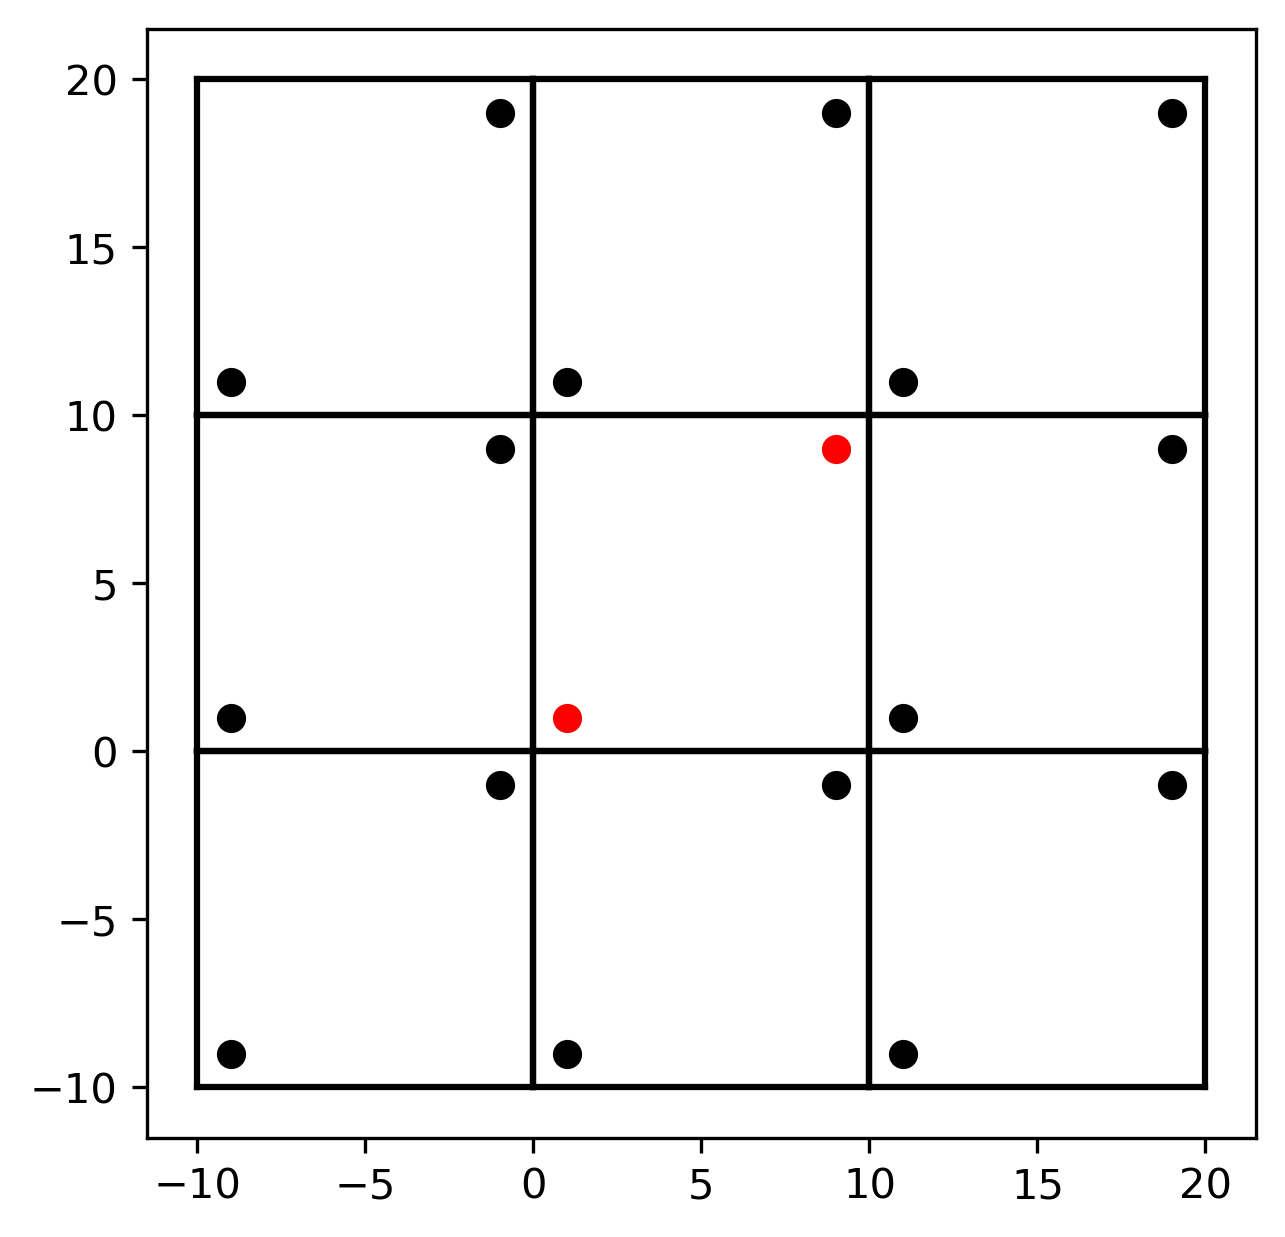

In [4]:
r1, r2 = np.array([0.9*L, 0.9*L]), np.array([0.1*L, 0.1*L]) 

for i in range(-1,2):
    for j in range(-1,2):
        if i == 0 and j == 0:
            plt.plot(r1[0]+i*L, r1[1]+j*L, 'ro')  # Plot in red
            plt.plot(r2[0]+i*L, r2[1]+j*L, 'ro')  # Plot in blue
        else:
            plt.plot(r1[0]+i*L, r1[1]+j*L, 'ko')  # Plot in black
            plt.plot(r2[0]+i*L, r2[1]+j*L, 'ko')  # Plot in black

        plt.plot([i*L, (i+1)*L], [j*L, j*L], 'k-')  # Horizontal side
        plt.plot([i*L, i*L], [j*L, (j+1)*L], 'k-')  # Vertical side
        plt.plot([(i+1)*L, (i+1)*L], [j*L, (j+1)*L], 'k-')  # Vertical side
        plt.plot([i*L, (i+1)*L], [(j+1)*L, (j+1)*L], 'k-')  # Horizontal side

plt.gca().set_aspect('equal', adjustable='box')


In [5]:
def pair_vector(r1,r2,L):
    """Calculate the vector r1 - r2 with periodic boundary conditions."""
    r = r2 - r1
    r -= np.rint(r / L) * L
    return r

Let's calculate the force acting on a particle due to another particle. We need to make sure to cut the force off for $r > r_c$.

In [6]:
def force(r):
    """Calculate the force on particle 1 due to particle 2."""
    r_mag = np.linalg.norm(r)
    if r_mag < rc:
        return (-48/r_mag**14 + 24/r_mag**8) * r
    else:
        return np.zeros(2)

## 4. Equations of motion 

The equation of motion for particle $i$ at time $t$ is given by Newton's equation: 

$$m \ddot{ \vec r}_i = \sum_j \vec F_{j \to i}$$

Where the sum runs over all particles $j \neq i$ and $\vec F_{j \to i}$ is the force exerted on particle $i$ by particle $j.$ Hence, at every step of our simulation, we need to know what is the net force felt by all particles. Let's write a function which takes in the positions of our particles and stores the force felt by each particle.

In [7]:
def get_forces(positions,L):
    """Calculate the forces on all particles."""
    forces = np.zeros_like(positions)
    for i in range(N):
        for j in range(i+1,N):
            r = pair_vector(positions[i],positions[j],L)
            forces[i] += force(r)
            forces[j] -= force(r) # Newton's third law
    return forces

## 5. Numerical integration
Now we need to find a way to perform a discrete integration of the equations of motion, that is, evolve the particles' positions from time $t \to t + \Delta t$. One naive way of doing this would be to Taylor expand $\vec r(t+ \Delta t)$:

$$\vec r_i(t+ \Delta t) = \vec r_i(t) + \vec r_i'(t) \Delta t + \frac 12 \vec r_i''(t) \Delta t^2 + \frac 1{3!} \vec r_i'''(t) \Delta t^3 + \mathcal{O}(\Delta t^4)$$

In fact, $\vec r_i'(t) = \vec v_i(t)$ and $\vec r ''(t) = \vec a_i(t) = \sum_j \vec F_{j \to i}/m$ the third derivative of the positions with respect to time is called the *jerk*. The above equation allows us to compute the position of a particle at the next timestep up to an error of order $\Delta t^4$. However, we need to store the velocities, the forces and the jerk. Computing all these quantities is very expensive and we can do better. 

We can use the **Verlet integration method** to do this more efficiently. First, let's rewrite an equation like the one above for $\vec r(t-\Delta t)$ (position at the previous timestep): 

$$\vec r_i(t- \Delta t) = \vec r_i(t) - \vec r_i'(t) \Delta t + \frac 12 \vec r_i''(t) \Delta t^2 - \frac 1{3!} \vec r_i'''(t) \Delta t^3 + \mathcal{O}(\Delta t^4)$$

We see that by adding the two equations we make the velocity and jerk terms vanish! That means that we can get the positions at the next timestep up to errors of order $\Delta t^4$ using only the positions at the previous timestep and the acceleration (which we just computed): 

$$ \vec r_i(t + \Delta t ) = 2 \vec r_i(t) -\vec r_i(t - \Delta t)+  \frac 1m \sum_j \vec F_{j \to i}$$ 

Let's write a function which evolves our system using this integration method.



In [8]:
def step(positions, velocities, L,dt): 
    
    forces = get_forces(positions, L)
    positions[:] = positions + velocities*dt + 0.5*forces*dt**2
    next_forces = get_forces(positions, L)
    velocities[:] = velocities + 0.5*(forces + next_forces)*dt
    return positions, velocities


## 6. That's it! Now it's time to animate our particles! 

In [9]:
velocities -= np.mean(velocities, axis=0) # Remove any drift velocity
def animate(positions, velocities, L, nsteps):
    all_positions = np.zeros((nsteps, N, 2))
    all_velocities = np.zeros_like(all_positions)
    for i in range(nsteps):
        all_positions[i] = positions
        all_velocities[i] = velocities
        positions, velocities = step(positions, velocities, L,dt)


    return all_positions, all_velocities



all_positions, all_velocities = animate(positions, velocities, L, nsteps)



In [10]:
all_positions.shape

(2000, 100, 2)

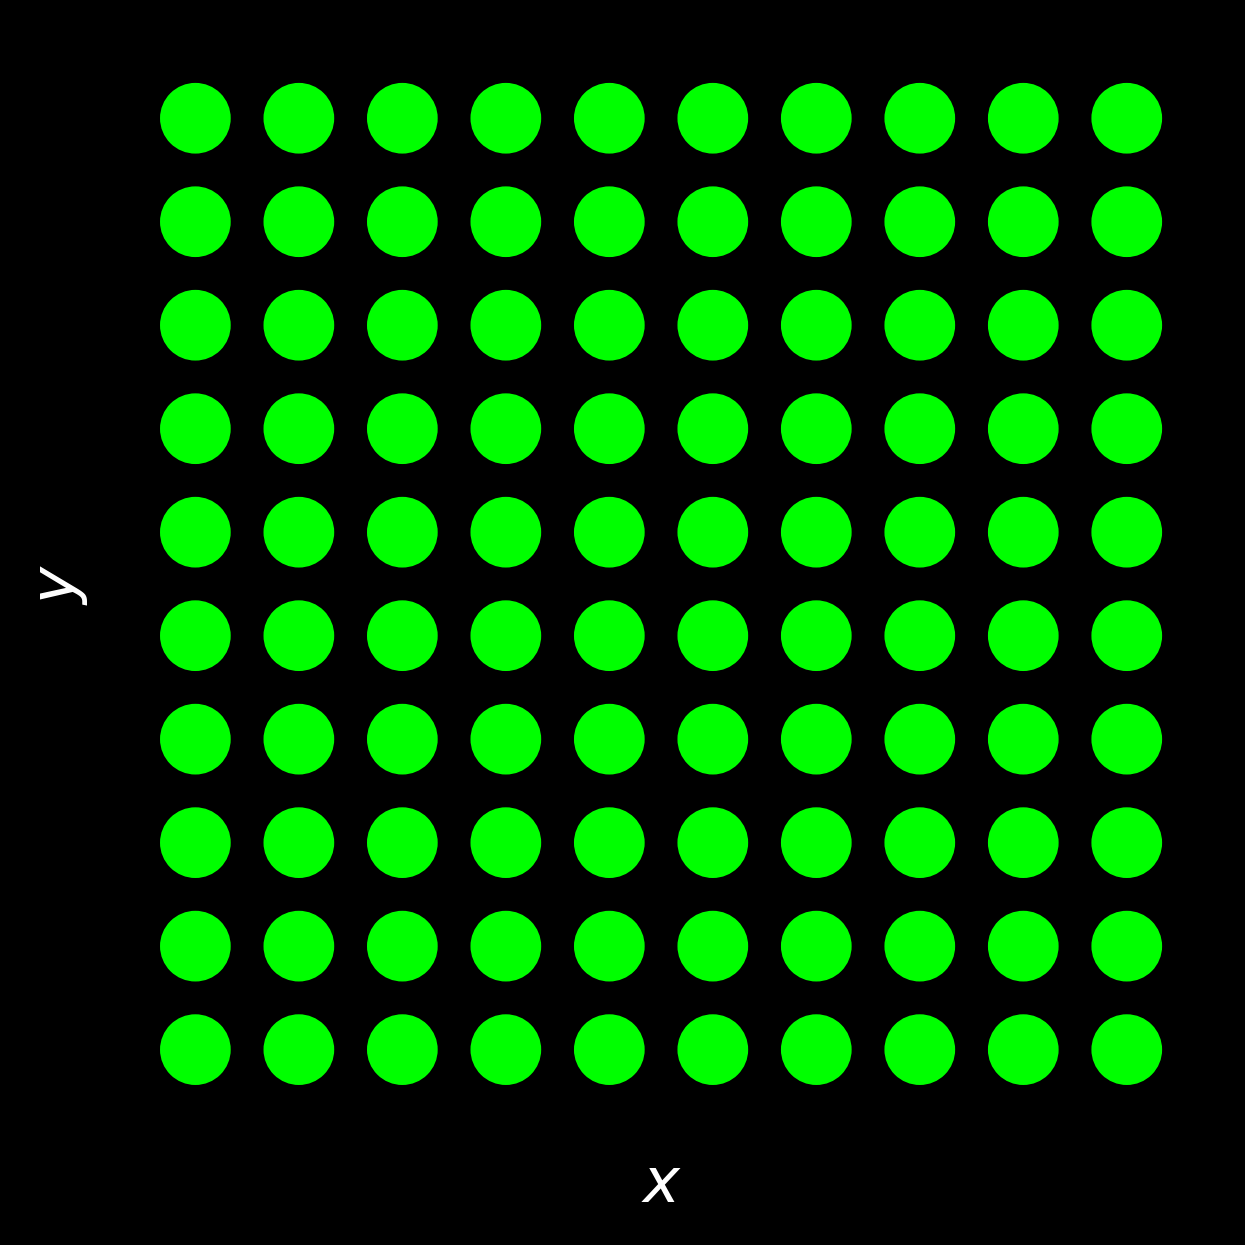

In [11]:
fig,ax = plt.subplots()

# Set the background color to black
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

def animate_positions(frame):
    ax.clear()
    # Set the background color to black for each frame
    ax.set_facecolor('black')
    for i in range(N):
        x, y = (all_positions[frame,i, 0])%L, (all_positions[frame, i, 1])%L
        # Set the ball color to fluorescent
        circle = plt.Circle((x, y),radius, fill=True, color='lime')
        ax.add_artist(circle)

    ax.set_xlabel('$x$', fontsize=15, color='white')
    ax.set_ylabel('$y$', fontsize=15, color='white')
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect('equal')
    ax.set_xticks([]) #remove ticks
    ax.set_yticks([])

interval = duration*1e3/nsteps
ani = animation.FuncAnimation(fig, animate_positions, frames=nsteps, interval=interval)
ani.save('lennard_jones_simulation.mp4', writer='ffmpeg')


In [12]:

def get_center_of_mass(positions):
    """Calculate the center of mass at all times."""
    center_of_mass = np.mean(positions, axis=0)
    return center_of_mass

center_of_mass = get_center_of_mass(all_positions)
print(center_of_mass)



[[ 2.13906603e-01  4.51896940e-01]
 [ 3.47010978e-01  2.61533540e+00]
 [ 6.46628304e-01  2.55963683e+00]
 [ 1.82772059e-01  1.59764077e+00]
 [ 2.07300047e+00  5.26125373e+00]
 [ 9.89806004e-01  5.38640577e+00]
 [-1.07974668e+00  7.03533256e+00]
 [ 2.64995182e-01  6.69735235e+00]
 [ 1.40866389e+00  1.02166940e+01]
 [ 1.38598606e+00  1.02712863e+01]
 [ 2.46600118e-01  2.42644185e-01]
 [ 1.32105447e+00  1.86332454e+00]
 [ 1.52359296e+00  2.59596697e+00]
 [ 1.32000561e+00  4.33446541e+00]
 [ 2.20527640e+00  3.82068617e+00]
 [ 3.09684013e+00  7.43483427e+00]
 [ 6.56197036e-01  6.60798351e+00]
 [ 1.48093104e+00  8.46941652e+00]
 [ 2.87864004e-01  8.79424624e+00]
 [ 1.81078371e+00  9.67106520e+00]
 [ 2.96546976e+00  1.73515341e-01]
 [ 2.17813970e+00  2.37574081e+00]
 [ 2.85506980e+00  1.40770125e+00]
 [ 1.59099532e+00  3.79762783e+00]
 [ 3.57833999e+00  3.10670170e+00]
 [ 1.66448495e+00  6.18727549e+00]
 [-3.70325552e-01  7.92980235e+00]
 [ 2.42586121e+00  8.42991670e+00]
 [ 3.83435463e+00  5